In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor

# RBF 
from sklearn.kernel_approximation import RBFSampler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

In [2]:
X_df = pd.read_csv("smartphone_battery_features.csv")
y_df = pd.read_csv("smartphone_battery_targets.csv")
# load the dataset

In [3]:
X_df.shape, y_df.shape
# rows and coloums

((5000, 15), (5000, 3))

In [4]:
X_df.columns
# coloum names

Index(['Device_ID', 'device_age_months', 'battery_capacity_mah',
       'avg_screen_on_hours_per_day', 'avg_charging_cycles_per_week',
       'avg_battery_temp_celsius', 'fast_charging_usage_percent',
       'overnight_charging_freq_per_week', 'gaming_hours_per_week',
       'video_streaming_hours_per_week', 'background_app_usage_level',
       'signal_strength_avg', 'charging_habit_score', 'usage_intensity_score',
       'thermal_stress_index'],
      dtype='object')

In [5]:
y_df.columns
# target coloum names

Index(['Device_ID', 'current_battery_health_percent', 'recommended_action'], dtype='object')

In [6]:
y = y_df['current_battery_health_percent']   # use exact column name
# declare target

In [7]:
X_df.info()
y_df.info()
#info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Device_ID                         5000 non-null   object 
 1   device_age_months                 5000 non-null   int64  
 2   battery_capacity_mah              5000 non-null   int64  
 3   avg_screen_on_hours_per_day       5000 non-null   float64
 4   avg_charging_cycles_per_week      5000 non-null   float64
 5   avg_battery_temp_celsius          5000 non-null   float64
 6   fast_charging_usage_percent       5000 non-null   float64
 7   overnight_charging_freq_per_week  5000 non-null   int64  
 8   gaming_hours_per_week             5000 non-null   float64
 9   video_streaming_hours_per_week    5000 non-null   float64
 10  background_app_usage_level        5000 non-null   object 
 11  signal_strength_avg               5000 non-null   object 
 12  chargi

In [8]:
X_df.isnull().sum()
y.isnull().sum()
# null values

np.int64(0)

In [9]:
df = pd.concat([X_df, y], axis=1)
# concat 2 csv files 

In [10]:
df.describe()


,device_age_months,battery_capacity_mah,avg_screen_on_hours_per_day,avg_charging_cycles_per_week,avg_battery_temp_celsius,fast_charging_usage_percent,overnight_charging_freq_per_week,gaming_hours_per_week,video_streaming_hours_per_week,charging_habit_score,usage_intensity_score,thermal_stress_index,current_battery_health_percent
count,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,24.232400,4134.700000,5.514120,8.33224,31.907360,50.712400,3.465200,4.012920,10.020740,6.582000,9.998394,3.079366,62.595600
std,14.138004,745.061698,1.974704,3.03454,2.544528,22.227398,2.306307,2.834289,4.990648,1.225225,0.058542,0.674274,17.723528
min,0.000000,3000.000000,1.000000,3.00000,21.600000,1.100000,0.000000,0.000000,0.000000,3.000000,6.570000,1.000000,10.000000
25%,12.000000,4000.000000,4.200000,6.10000,30.200000,33.500000,1.000000,1.900000,6.600000,6.000000,10.000000,2.620000,50.200000
50%,24.000000,4500.000000,5.500000,8.25000,31.900000,51.000000,3.000000,3.300000,10.000000,7.000000,10.000000,3.070000,64.100000
75%,36.000000,5000.000000,6.900000,10.40000,33.600000,68.100000,5.000000,5.400000,13.400000,7.000000,10.000000,3.520000,76.900000
max,48.000000,5000.000000,12.000000,18.60000,41.200000,99.100000,7.000000,24.800000,27.200000,10.000000,10.000000,6.180000,100.000000


In [11]:
# Check what background_app_usage_level and signal_strength_avg look like
print("=== Background App Usage Level ===")
print(X_df['background_app_usage_level'].value_counts())
print(f"\nData type: {X_df['background_app_usage_level'].dtype}")
print(f"Unique values: {X_df['background_app_usage_level'].nunique()}")

print("\n=== Signal Strength Avg ===")
print(X_df['signal_strength_avg'].value_counts())
print(f"\nData type: {X_df['signal_strength_avg'].dtype}")
print(f"Unique values: {X_df['signal_strength_avg'].nunique()}")

=== Background App Usage Level ===
background_app_usage_level
Low       1707
Medium    1684
High      1609
Name: count, dtype: int64

Data type: object
Unique values: 3

=== Signal Strength Avg ===
signal_strength_avg
Good        3025
Moderate    1509
Poor         466
Name: count, dtype: int64

Data type: object
Unique values: 3


In [12]:
# Create working copy
X_df_encoded = X_df.copy()

# Ordinal encoding with proper order
background_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
signal_mapping = {'Poor': 0, 'Moderate': 1, 'Good': 2}

X_df_encoded['background_app_usage_level'] = X_df_encoded['background_app_usage_level'].map(background_mapping)
X_df_encoded['signal_strength_avg'] = X_df_encoded['signal_strength_avg'].map(signal_mapping)

print(" Encoded background_app_usage_level: Low=0, Medium=1, High=2")
print(" Encoded signal_strength_avg: Poor=0, Moderate=1, Good=2\n")

# Verify encoding
print("Encoded values for background_app_usage_level:", sorted(X_df_encoded['background_app_usage_level'].unique()))
print("Encoded values for signal_strength_avg:", sorted(X_df_encoded['signal_strength_avg'].unique()))


 Encoded background_app_usage_level: Low=0, Medium=1, High=2
 Encoded signal_strength_avg: Poor=0, Moderate=1, Good=2

Encoded values for background_app_usage_level: [np.int64(0), np.int64(1), np.int64(2)]
Encoded values for signal_strength_avg: [np.int64(0), np.int64(1), np.int64(2)]



=== STEP 2: Creating Complete Correlation Matrix ===



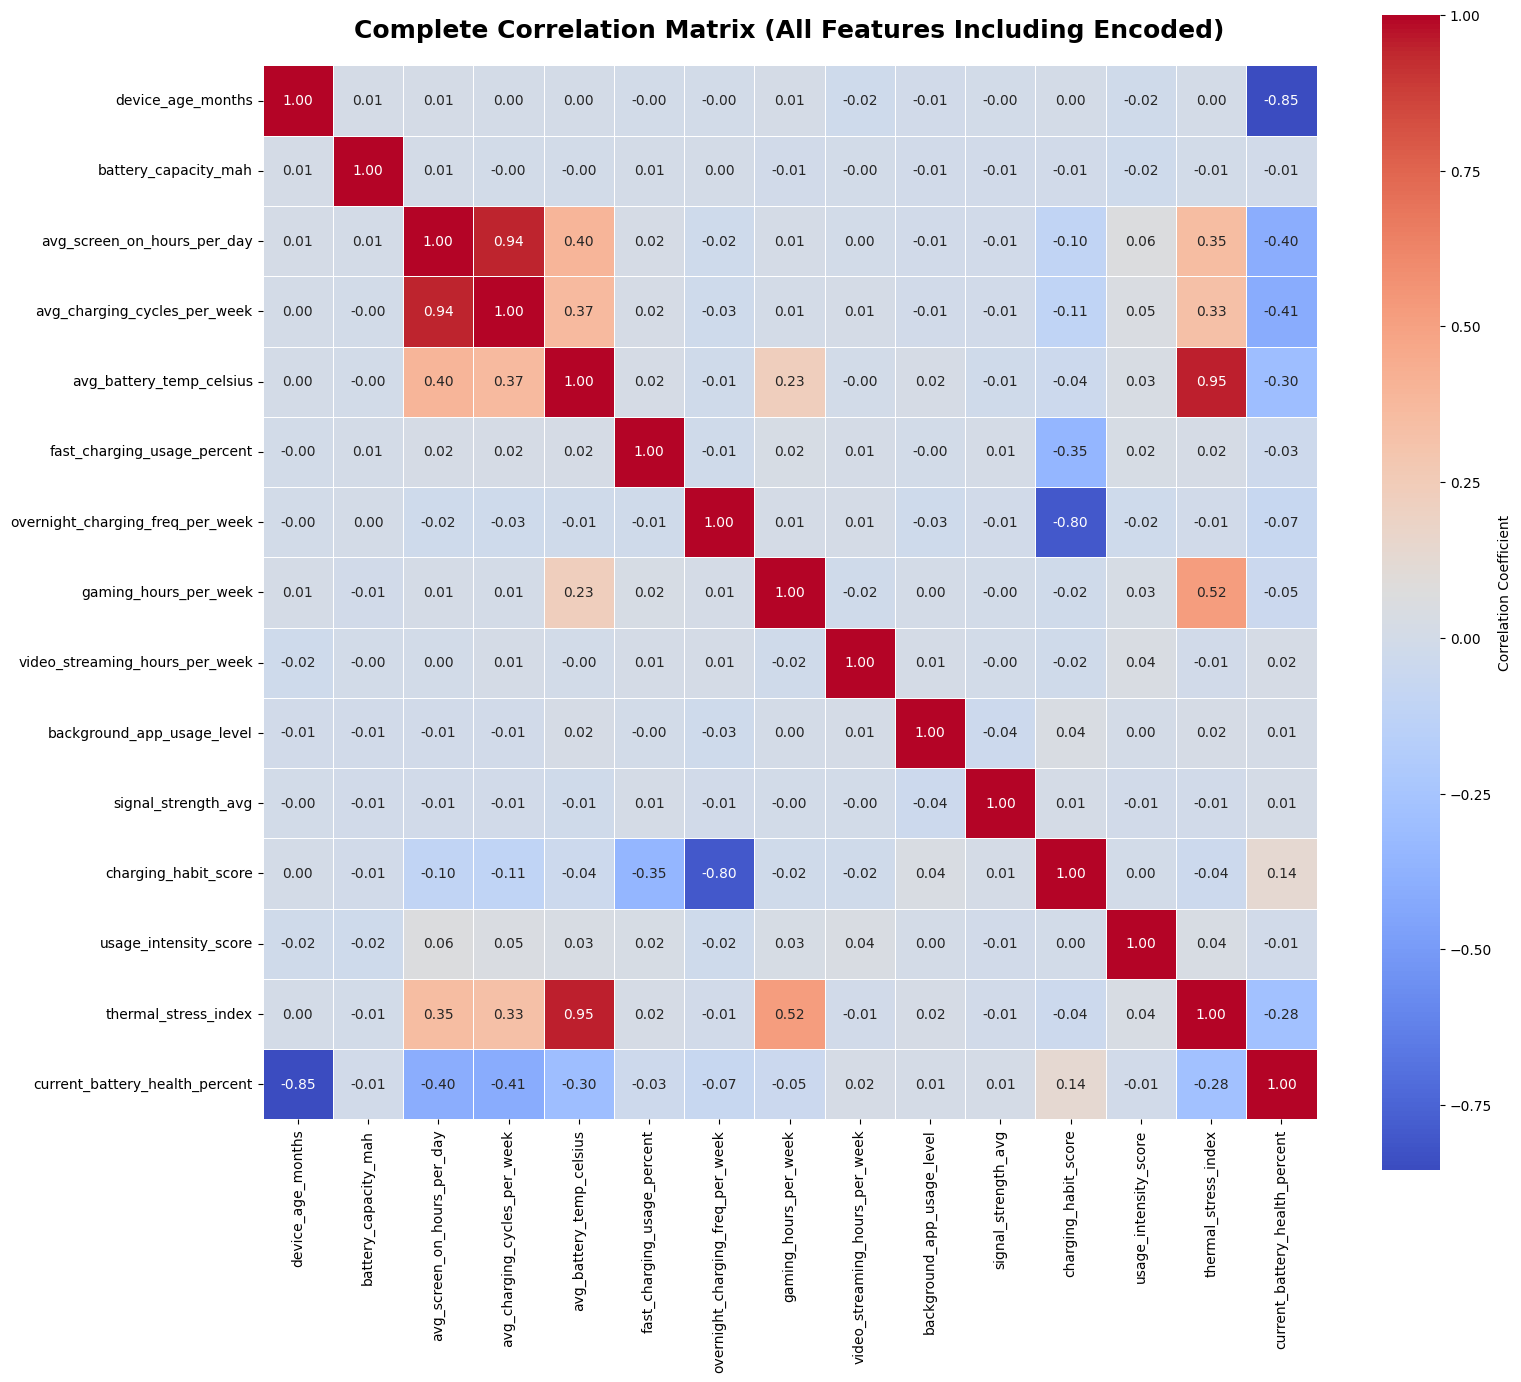

In [13]:
print("\n=== STEP 2: Creating Complete Correlation Matrix ===\n")

# Remove ONLY Device_ID (it's just an identifier)
X_for_analysis = X_df_encoded.drop(columns=['Device_ID'])

# Combine with target
df_complete = pd.concat([X_for_analysis, y], axis=1)

# Calculate correlation matrix
correlation_matrix = df_complete.corr()

# Visualize
plt.figure(figsize=(16, 14))
sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    square=True,
    cbar_kws={'label': 'Correlation Coefficient'}
)
plt.title("Complete Correlation Matrix (All Features Including Encoded)", 
          fontsize=18, pad=20, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
print("\n=== STEP 3: Analyzing Correlations ===\n")

# A) Correlation with Target (Battery Health)
print("📊 CORRELATION WITH TARGET (current_battery_health_percent):\n")
target_corr = correlation_matrix['current_battery_health_percent'].drop('current_battery_health_percent').sort_values(key=abs, ascending=False)
print(target_corr.to_string())

print("\n" + "="*60)

# B) High correlations BETWEEN features (multicollinearity check)
print("MULTICOLLINEARITY CHECK (Correlations > 0.85 between features):\n")

high_corr_pairs = []
feature_columns = [col for col in correlation_matrix.columns if col != 'current_battery_health_percent']

for i in range(len(feature_columns)):
    for j in range(i+1, len(feature_columns)):
        corr_value = correlation_matrix.loc[feature_columns[i], feature_columns[j]]
        if abs(corr_value) > 0.85:
            high_corr_pairs.append({
                'Feature 1': feature_columns[i],
                'Feature 2': feature_columns[j],
                'Correlation': round(corr_value, 3)
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', key=abs, ascending=False)
    print(high_corr_df.to_string(index=False))
    print(f"\nFound {len(high_corr_pairs)} pairs with high correlation!")
else:
    print("No problematic multicollinearity detected (all correlations < 0.85)")



=== STEP 3: Analyzing Correlations ===

📊 CORRELATION WITH TARGET (current_battery_health_percent):

device_age_months                  -0.854140
avg_charging_cycles_per_week       -0.409962
avg_screen_on_hours_per_day        -0.399347
avg_battery_temp_celsius           -0.300765
thermal_stress_index               -0.280187
charging_habit_score                0.137861
overnight_charging_freq_per_week   -0.067161
gaming_hours_per_week              -0.049027
fast_charging_usage_percent        -0.033425
video_streaming_hours_per_week      0.018082
background_app_usage_level          0.014968
usage_intensity_score              -0.013157
battery_capacity_mah               -0.011077
signal_strength_avg                 0.008209

MULTICOLLINEARITY CHECK (Correlations > 0.85 between features):

                  Feature 1                    Feature 2  Correlation
   avg_battery_temp_celsius         thermal_stress_index        0.952
avg_screen_on_hours_per_day avg_charging_cycles_per_week      

In [15]:
X_df = X_df.select_dtypes(include=[np.number])


In [16]:
X = X_df.copy()


In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [19]:
X_df.dtypes

device_age_months                     int64
battery_capacity_mah                  int64
avg_screen_on_hours_per_day         float64
avg_charging_cycles_per_week        float64
avg_battery_temp_celsius            float64
fast_charging_usage_percent         float64
overnight_charging_freq_per_week      int64
gaming_hours_per_week               float64
video_streaming_hours_per_week      float64
charging_habit_score                  int64
usage_intensity_score               float64
thermal_stress_index                float64
dtype: object

In [20]:
#base line linear regression model for comparison
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression RMSE: 4.684694661840321
Linear Regression R2: 0.9299077439728853


In [21]:
from sklearn.cluster import KMeans
from sklearn.metrics import pairwise_distances
from sklearn.linear_model import Ridge

In [22]:
class RBFNetwork:
    def __init__(self, n_centers=100, alpha=1.0, gamma=None):
        self.n_centers = n_centers
        self.alpha = alpha
        self.gamma = gamma

    def fit(self, X, y):
        self.kmeans_ = KMeans(n_clusters=self.n_centers, random_state=42, n_init=10)
        self.kmeans_.fit(X)
        self.centers_ = self.kmeans_.cluster_centers_

        if self.gamma is None:
            dists = pairwise_distances(self.centers_)
            np.fill_diagonal(dists, np.inf)
            sigma = dists.min(axis=1).mean()
            self.gamma_ = 1 / (2 * sigma ** 2)
        else:
            self.gamma_ = self.gamma

        X_rbf = self._transform(X)
        self.ridge_ = Ridge(alpha=self.alpha)
        self.ridge_.fit(X_rbf, y)
        return self

    def predict(self, X):
        return self.ridge_.predict(self._transform(X))

    def _transform(self, X):
        diff = X[:, np.newaxis, :] - self.centers_[np.newaxis, :, :]
        sq_dists = np.sum(diff ** 2, axis=2)
        return np.exp(-self.gamma_ * sq_dists)

In [23]:

results = []

for n_centers in [200, 500, 1000]:
    for alpha in [0.01, 0.1, 1.0]:
        model = RBFNetwork(n_centers=n_centers, alpha=alpha)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        results.append((n_centers, alpha, round(r2, 4)))
        print(f"n_centers={n_centers}, alpha={alpha} → R²={r2:.4f}")

# Best combo
best = max(results, key=lambda x: x[2])
print(f"\nBest: n_centers={best[0]}, alpha={best[1]}, R²={best[2]}")

n_centers=200, alpha=0.01 → R²=0.9312
n_centers=200, alpha=0.1 → R²=0.9246
n_centers=200, alpha=1.0 → R²=0.9069
n_centers=500, alpha=0.01 → R²=0.9357
n_centers=500, alpha=0.1 → R²=0.9316
n_centers=500, alpha=1.0 → R²=0.9162
n_centers=1000, alpha=0.01 → R²=0.9414
n_centers=1000, alpha=0.1 → R²=0.9385
n_centers=1000, alpha=1.0 → R²=0.9267

Best: n_centers=1000, alpha=0.01, R²=0.9414


In [24]:
results2 = []

for n_centers in [1500, 2000, 2500]:
    for alpha in [0.001, 0.01]:
        model = RBFNetwork(n_centers=n_centers, alpha=alpha)
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        r2 = r2_score(y_test, y_pred)
        results2.append((n_centers, alpha, round(r2, 4)))
        print(f"n_centers={n_centers}, alpha={alpha} → R²={r2:.4f}")

best = max(results2, key=lambda x: x[2])
print(f"\nBest: n_centers={best[0]}, alpha={best[1]}, R²={best[2]}")

n_centers=1500, alpha=0.001 → R²=0.9417
n_centers=1500, alpha=0.01 → R²=0.9419
n_centers=2000, alpha=0.001 → R²=0.9407
n_centers=2000, alpha=0.01 → R²=0.9419
n_centers=2500, alpha=0.001 → R²=0.9366
n_centers=2500, alpha=0.01 → R²=0.9385

Best: n_centers=1500, alpha=0.01, R²=0.9419


In [25]:
rbf_true = RBFNetwork(n_centers=1500, alpha=0.01)
rbf_true.fit(X_train_scaled, y_train)
y_pred_rbf = rbf_true.predict(X_test_scaled)

print(f"Linear Regression R²: {r2_score(y_test, y_pred_lr):.4f}")
print(f"True RBF Network R²:  {r2_score(y_test, y_pred_rbf):.4f}")

Linear Regression R²: 0.9299
True RBF Network R²:  0.9419


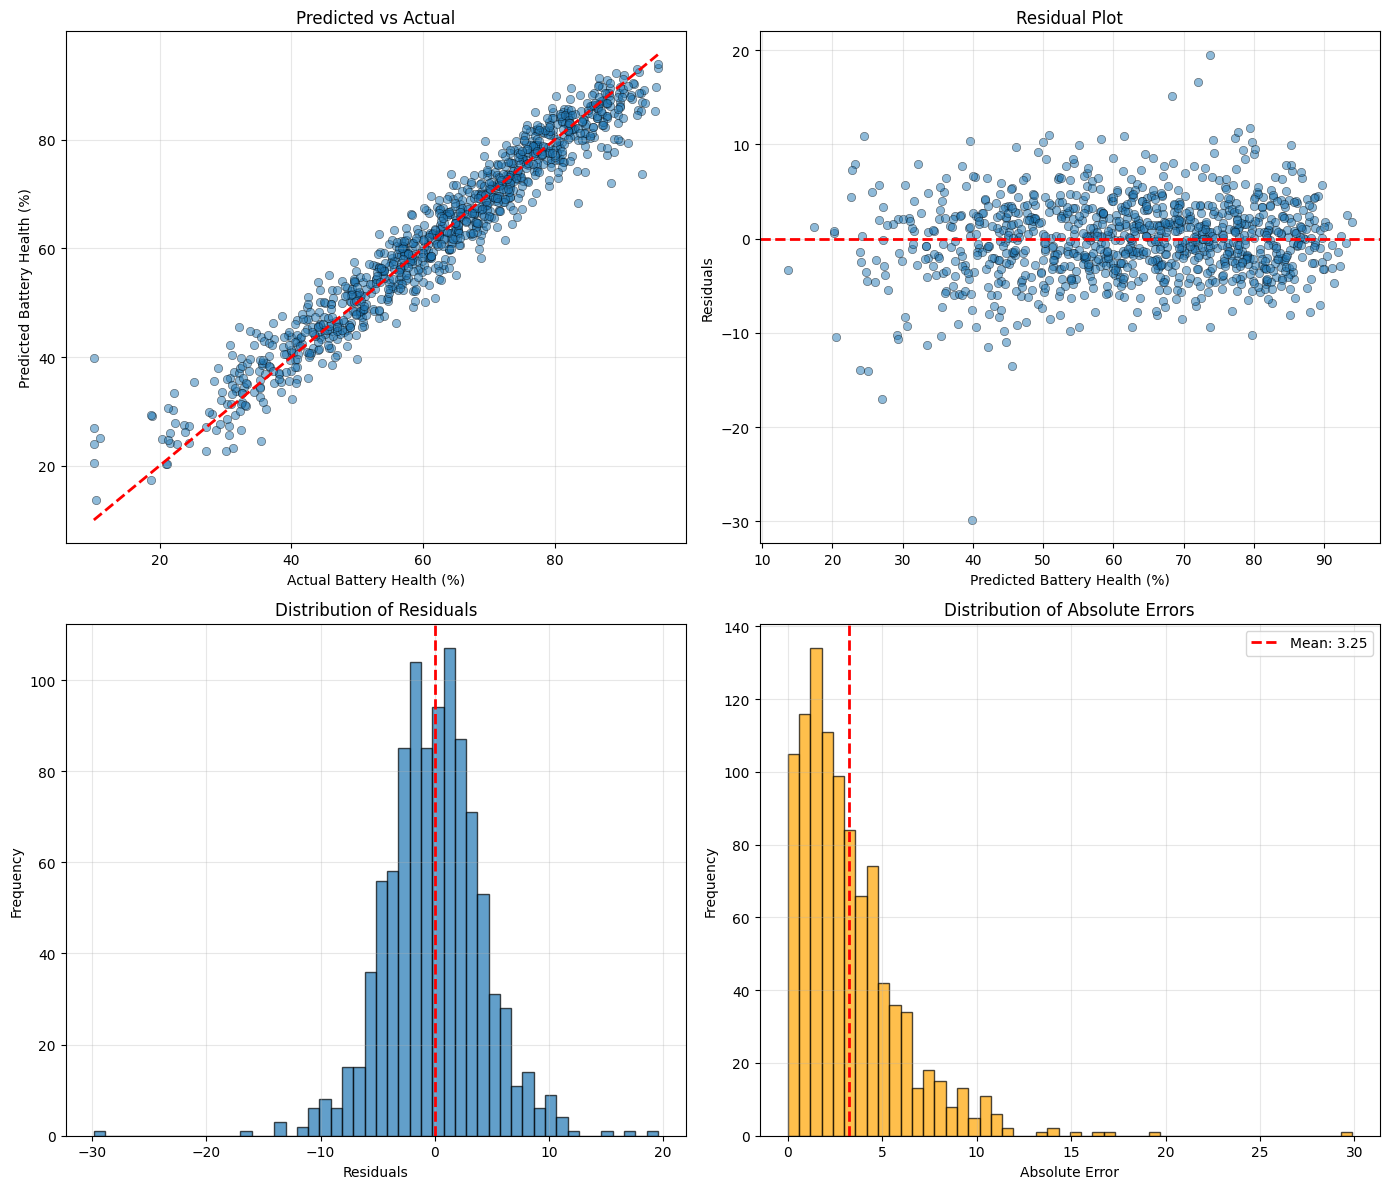


Residual Statistics:
Mean Residual: -0.0501
Std Residual: 4.2687
Min Error: 0.0032
Max Error: 29.8630
Mean Absolute Error: 3.2549


In [26]:
# Create a figure with multiple subplots for comprehensive evaluation
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Predicted vs Actual
axes[0, 0].scatter(y_test, y_pred_rbf, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Battery Health (%)')
axes[0, 0].set_ylabel('Predicted Battery Health (%)')
axes[0, 0].set_title('Predicted vs Actual')
axes[0, 0].grid(True, alpha=0.3)

# 2. Residuals plot
residuals = y_test - y_pred_rbf
axes[0, 1].scatter(y_pred_rbf, residuals, alpha=0.5, edgecolors='k', linewidth=0.5)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Battery Health (%)')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residual Plot')
axes[0, 1].grid(True, alpha=0.3)

# 3. Residuals distribution
axes[1, 0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[1, 0].set_xlabel('Residuals')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Residuals')
axes[1, 0].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1, 0].grid(True, alpha=0.3)

# 4. Error distribution
errors = np.abs(residuals)
axes[1, 1].hist(errors, bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1, 1].set_xlabel('Absolute Error')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Distribution of Absolute Errors')
axes[1, 1].axvline(x=errors.mean(), color='r', linestyle='--', lw=2, label=f'Mean: {errors.mean():.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print additional statistics
print(f"\nResidual Statistics:")
print(f"Mean Residual: {residuals.mean():.4f}")
print(f"Std Residual: {residuals.std():.4f}")
print(f"Min Error: {errors.min():.4f}")
print(f"Max Error: {errors.max():.4f}")
print(f"Mean Absolute Error: {errors.mean():.4f}")

In [27]:
print(f"Linear Regression R2: {r2_score(y_test, y_pred_lr):.4f}")
print(f"RBF Network R2:       {r2_score(y_test, y_pred_rbf):.4f}")

Linear Regression R2: 0.9299
RBF Network R2:       0.9419
